In [68]:
import pandas as pd
import sys
sys.path.append("./../src")
import utils
from setfit import SetFitModel
import ollama
from rouge_score import rouge_scorer
import requests
import json
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt


In [2]:
UK="./../data/ParlEE_UK_plenary_speeches.csv"

In [3]:
df=pd.read_csv(UK)

/var/folders/06/25_1mnt97hq60zy5672y3qzw0000gn/T/ipykernel_26971/3409319351.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(UK)


In [4]:
#usato giusto per fare qualche test più veloce senza che ci metta tre ore a task
df_small=df[df['date']>='2018-01-01']

In [5]:
records = {
    "nuclear":{
        'keywords':[
            "Power plant",
            "Nuclear power generation",
            "Decommissioning",
            "Nuclear fuel",
            "Radioactivity",
            "Radioactive waste",
            "Energy base load power source",
            "Fukushima",
            "Chernobyl",
            "Daiichi Nuclear Power Plant",
            # General nuclear-energy vocabulary
            "Nuclear reactors",
            "Pressurised Water Reactor",
            "Advanced Gas-cooled Reactor",
            "Small Modular Reactors",
            "Advanced Modular Reactors",
            "Nuclear fission",
            "Nuclear fusion",
            "Uranium enrichment",
            "Fuel reprocessing",
            "Spent fuel management",
            "Nuclear contamination",
            "Nuclear decontamination",
            "Radiation leakage",
            # UK-specific nuclear infrastructure
            "Hinkley Point C",
            "Sizewell C",
            "Wylfa Newydd",
            "Oldbury",
            "Bradwell B",
            "Sellafield",
            "Dounreay",
            "Magnox reactors",
            "Office for Nuclear Regulation",
            "Nuclear Decommissioning Authority",
            "Energy Security Strategy",
            "Regulated Asset Base model",
            "RAB model",
            # Political and policy themes
            "Nuclear financing",
            # Risk and crisis terms
            "Nuclear meltdown",
            "Core containment",
            "Emergency cooling system",
            # Geopolitical and supply chain
            "Uranium supply chain",
            "Nuclear cooperation agreements",
            "Russian uranium",
            ],
        'policyarea':[7, 8],
        
        },

    "climate change": {
        'keywords':
            ["global warming",
             "greenhouse gases", "carbon emissions", "renewable energy", "sustainability",  
             "climate mitigation", "COP26", "Paris Agreement"],
        'policyarea':[8],
        
        },
    "Gaza":{ 
        'keywords': [
            # Israeli political figures
            "Netanyahu",
            "Benjamin Netanyahu",
            "Ehud Olmert",
            "Ariel Sharon",
            "Ehud Barak",
            "Tzipi Livni",
            "Naftali Bennett",
            "Yair Lapid",
            "Avigdor Lieberman",
            "Shimon Peres",
            "Isaac Herzog",
            "Reuven Rivlin",
            "Benny Gantz",
            "Yoav Gallant",
            "Ben Gvir",
            "Zionism", "Zionist", "anti-zionist", "anti-zionism",

            # Palestinian political figures
            "Mahmoud Abbas",
            "Abu Mazen",
            "Ismail Haniyeh",
            "Yahya Sinwar",
            "Marwan Barghouti",
            "Saeb Erekat",
            "Mohammad Shtayyeh",
            "Khaled Mashal",
            "Ahmed Yassin",
            "Mohammed Deif",

            # Israeli institutions / organisations
            "Knesset",

            "Israel Defense Forces",
            "Shin Bet",
            "Mossad",
            "Likud",
            "Yesh Atid",
            "Blue and White",
            "Kadima",
            "Religious Zionism party",
            "Shas",
            "Meretz",

            # Palestinian institutions / organisations
            "Palestine Liberation Organization",
            "Fatah",
            "Hamas",
            "Popular Front for the Liberation of Palestine",
            "PFLP",
            "Al-Qassam Brigades",
            "Palestinian Legislative Council",

            # Key places (Gaza / Israel)
            "Gaza City",
            "Rafah",
            "Khan Younis",
            "Jabalia",
            "Beit Hanoun",
            "Deir al-Balah",
            "Shuja'iyya",
            "Nuseirat",
            "Beit Lahia",
            "Al-Shifa Hospital",

            # Key places (Israel)
            "Sderot",
            "Ashkelon",
            "Ashdod",
            "Beersheba",
            "Tel Aviv",
            "Jerusalem",
            "West Jerusalem",
            "East Jerusalem",
            "Haifa",
            "Eilat",

            # Crossings and checkpoints
            "Erez Crossing",
            "Kerem Shalom Crossing",
            "Rafah Crossing",
            "Qalandia",
            "Allenby Bridge Crossing",
            "Gilo checkpoint",

            # Named military operations (appear frequently in UK Parliament debates)
            "Operation Cast Lead",
            "Operation Pillar of Defense",
            "Operation Protective Edge",
            "Operation Guardian of the Walls",
            "Operation Breaking Dawn",
            "Operation Iron Swords",
            "Operation Summer Rains",
            "Operation Autumn Clouds",

            # International actors mentioned regarding the conflict
            "UNRWA",
            "UN Human Rights Council",
            "Quartet on the Middle East",
            

            # Other region-specific named entities
            "Al-Aqsa Mosque",
            "Temple Mount",
            "Haram al-Sharif",
            "Sheikh Jarrah",
            "Hebron",
            "Nablus",
            "Ramallah",
            "Bethlehem",
            "Jenin",

            # NGOs / rights groups mentioned often
            "B'Tselem",
            "Breaking the Silence",
            "ICRC"
        ],
        'policyarea':[16, 18, 19],
        
    }}

In [75]:
class StanceDetector:
    
    
    ''''
    GENERAL FUNCTIONING:
    1. Load speeches dataset in it, in speeches_df
    2. Filter the dataset according to a topic and its keyword list, put it in filtered_df 
        (this way it means that each instance of a class contains just a single topic since there is just one filtered_df
        which contains filtered speeches about one single topic, it can be solved in the future)
    3. Classify all the sentences in filtered_df in (non)opinionated. Add a classification column to filtered_df
    4. Take only the classified as opinionated and put them in classified_df
        At this point classified_df contains all the sentences with an opinion about a single topic.
        This is enough to track the amount of data available for each year.
        Classified_df will still contain metadata like date, author and party
    5. Summarize all the 'text' from classified_df into a new dataframe
    '''

    """
    The dataframe we'll be working on has the following columns:
    ['instance_id', 'date', 'agenda', 'speechnumber', 'sentencenumber',
       'speaker', 'party', 'text', 'parliament', 'iso3country', 'chair', 'eu',
       'policyarea', 'cmp_party']

    There is a big jsonfile we'll be working on, with the following structure:
    {
        "nuclear":{
            'keywords':[...],
            'policyarea':[7, 8],
            'df_filtered':...,
            'df_classified':...

        },
        
    }
    Thus there is going to be one class instance for each database. In each instance we'll have multiple topics 
    every topic will have its own keyword list, policyarea list, filtered dataframe and classified dataframe.
    """
    record=None
    filtered_df=None
    classified_df=None
    topic = None
    policyarea=[]

    def __init__( self, speech,records, classification_model_path='./../models/setfit-fewshot-opinions-1', cl_model_hf="andreacristiano/stancedetection"):
        self.speeches_df = speech
        self.record= records    
        self.classification_model_path= classification_model_path
        self.model= SetFitModel.from_pretrained(cl_model_hf)
    #AUXILIARY FUNCTIONS
    def get_records(self):
        return self.records
    
    def get_speeches(self):
        return self.speeches_df
    
    def get_filtered_speeches(self, topic):
        return self.records[topic]['df_filtered']
    
    def get_classified_speeches(self, topic):
        return self.records[topic]['df_classified']

    def format_discussion(self,agenda, date):
        
        """
        IN: a speech, identified uniquely by its agenda and date
        OUT: speech in dialogue format

        Format:
        speaker1 (party1): text
        speaker2 (party2): text
        ...
        """
        
        # Filter rows by both agenda and date
        discussion_df = self.speeches_df[(self.speeches_df['agenda'] == agenda) & (self.speeches_df['date'] == date)].copy()

        if discussion_df.empty:
            return f"No discussion found for agenda '{agenda}' on date '{date}'."

        # Sort by speechnumber and sentencenumber to maintain chronological order
        discussion_df.sort_values(by=['speechnumber', 'sentencenumber'], inplace=True)

        # Group sentences belonging to the same speech (same speechnumber, speaker, and party)
        grouped = (
            discussion_df
            .groupby(['speechnumber', 'speaker', 'party'])['text']
            .apply(' '.join)
            .reset_index()
        )

        # Format each speaker's speech
        formatted_lines = [f"{row['speaker']} ({row['party']}): {row['text']}" for _, row in grouped.iterrows()]

        # Join everything into one formatted discussion
        return "\n".join(formatted_lines)

        
    def add_record(self, topic, keywords, policyarea):
        """
        IN: topic name, list of keywords, list of policyarea codes
        """
        self.records[topic] = {
            'keywords':keywords,
            'policyarea':policyarea,
        }

    def __get_keywords_policyarea(self,topic):
        return self.record[topic]['keywords'], self.record[topic]['policyarea']
    
    #for testing purposes only  
    def __extract_keywords_from_sentence(self, sentence, topic):
        """
        Extract keywords that appear in a given sentence.
        
        Parameters:
        -----------
        sentence : str
            The sentence to search for keywords
        keywords : list
            List of keywords to search for
        
        Returns:
        --------
        list
            List of keywords found in the sentence
        """
        # Convert sentence to lowercase for case-insensitive matching
        sentence_lower = sentence.lower()
        
        # Find keywords that appear in the sentence
        found_keywords = []
        kws=self.record[topic]['keywords']
        for keyword in kws:
            if keyword.lower() in sentence_lower:
                found_keywords.append(keyword)
        
        return found_keywords

    #WORKFLOW FUNCTIONS
    def filter_speeches(self,topic):
        #https://www.comparativeagendas.net/pages/master-codebook 
        #here there's a list of policiarea codes for each topic, these will be integrated in the filtering to make it more effective.
        keywords, policyarea = self.__get_keywords_policyarea(topic)
        #filter the dataframe according to the policyarea values. policyarea is an array containing integers
        
        self.record[topic]['df_filtered']= self.speeches_df[self.speeches_df['policyarea'].isin(policyarea)]
        self.record[topic]['df_filtered'] = self.speeches_df[self.speeches_df['text'].str.contains('|'.join(keywords), case=False, na=False)]
        print("BRO")
        
        return self.record[topic]['df_filtered']

    def classify_filtered_sentences(self, topic):
        #TODO: an easier method to access single topic data inside the class can be made
        """"
        IN: filtered dataframe about a topic
        OUT: classified dataframe containing opinonated sentences only
             + a new column 'classification' in filtered dataframe
        """
        # Get the texts to classify from self.filtered_df
        texts = self.record[topic]['df_filtered']['text'].tolist()
        # Perform classification
        predictions = self.model.predict(texts)
        # Add predictions as a new column in self.filtered_df
        self.record[topic]['df_filtered']['classification'] = predictions
        self.record[topic]['df_classified'] = self.record[topic]['df_filtered'][self.record[topic]['df_filtered']['classification'] == 'opinion']
        return self.record[topic]['df_classified']
    

    def generate_anchors(self, topic, model_name='gemma3'):
        """
        Generate anchor sentences representing different stances on a topic.
        
        Parameters:
        -----------
        topic : str
            The topic to generate anchors for
        model_name : str
            Name of the Ollama model to use (default: 'gemma3')
        
        Returns:
        --------
        dict
            Dictionary with stance levels as keys and generated sentences as values
            Keys: 'strongly_favor', 'moderately_favor', 'neutral', 'moderately_against', 'strongly_against'
        """
        
        stance_levels = {
            'strongly_favor': f"Write a single parliamentary-style sentence expressing strong support for {topic}. Be clear and assertive.",
            'moderately_favor': f"Write a single parliamentary-style sentence expressing moderate support for {topic}. Show cautious approval.",
            'neutral': f"Write a single parliamentary-style sentence expressing a neutral or balanced view on {topic}. Show no clear preference.",
            'moderately_against': f"Write a single parliamentary-style sentence expressing moderate opposition to {topic}. Show concerns but not extreme rejection.",
            'strongly_against': f"Write a single parliamentary-style sentence expressing strong opposition to {topic}. Be clear and firm in disagreement."
        }
        
        system_prompt = """You are a UK parliamentary speech writer. Generate realistic parliamentary statements.
        Keep sentences concise and natural. Use appropriate parliamentary language.
        Return ONLY the sentence itself, without any preamble, explanation, or quotation marks."""
        
        anchors = {}
        
        print(f"Generating stance anchors for topic: {topic}")
        print("=" * 80)
        
        for stance, prompt in stance_levels.items():
            payload = {
                "model": model_name,
                "prompt": prompt,
                "system": system_prompt,
                "stream": False,
                "temperature": 0.7
            }
            
            try:
                response = requests.post(
                    "http://localhost:11434/api/generate",
                    json=payload,
                    timeout=60
                )
                response.raise_for_status()
                
                # Extract and clean the generated sentence
                generated_text = response.json()['response'].strip()
                # Remove quotes if present
                generated_text = generated_text.strip('"').strip("'")
                
                anchors[stance] = generated_text
                
                print(f"\n{stance.upper().replace('_', ' ')}:")
                print(f"  {generated_text}")
                
            except requests.exceptions.RequestException as e:
                print(f"\nError generating anchor for {stance}: {e}")
                anchors[stance] = f"ERROR: {str(e)}"
        
        print("\n" + "=" * 80)
        print(f"Generated {len(anchors)} anchor sentences")
        
        # Store anchors in the record for this topic
        self.record[topic]['anchors'] = anchors
        
        return anchors

    
    def summarize(self, topic, model_name='gemma3'):

        system_prompt = f"""You are summarizing speeches from the UK Parliament about {topic}. 
        Focus on capturing the speaker's stance or position regarding {topic}. 
        Provide brief, concise summaries that clearly indicate whether the speaker supports, opposes, or has a nuanced view on {topic}.
        Keep summaries to 1-2 sentences maximum. if the speech does not express any stance on {topic}, reply NO"""

        classified_df=self.record[topic]['df_classified']
        #summarize every sentence in classified_df and add it to a new column 'summary'
        summaries = []
        for idx, row in classified_df.iterrows():
            speech_text = row['text']
            # Prepare the request to Ollama API
            payload = {
                "model": model_name,
                "prompt": f"Summarize this parliamentary speech about {topic}, focusing on the speaker's stance:\n\n{speech_text}",
                "system": system_prompt,
                "stream": False
            }
            try:
                # Call Ollama API (default runs on localhost:11434)
                response = requests.post(
                    "http://localhost:11434/api/generate",
                    json=payload,
                    timeout=60
                )
                response.raise_for_status()
                
                # Extract the summary from response
                summary = response.json()['response'].strip()
                summaries.append(summary)
            except requests.exceptions.RequestException as e:
                print(f"\nError processing sample {idx}: {e}")
                summaries.append(f"ERROR: {str(e)}")
        #remove all the summaries whose text is 'NO' or start with 'Please provide'
        classified_df['summary'] = summaries
        self.record[topic]['df_classified'] = classified_df
        return classified_df
    
    def summarize_parliamentary_speeches(self, model_name, num_samples, topic):
        """
        Summarize random samples from UK parliamentary speeches using Ollama.
        Computes ROUGE scores, extracts keywords, and displays results.
        
        Parameters:
        -----------
        we start on a classified dataframe
        model_name : str
            Name of the Ollama model to use (e.g., 'llama2', 'mistral')
        num_samples : int
            Number of random samples to extract and summarize
        topic : str
            The topic that all speeches are about (e.g., 'climate change', 'Brexit')
        keywords : list
            List of keywords to search for in each sentence
        
        Returns:
        --------
        pd.DataFrame
            DataFrame with columns: 'original_text', 'summary', 'keywords', 'rouge1', 'rouge2', 'rougeL'
        """
        # Extract random samples keeping only the 'text' column
        classified_df=self.record[topic]['df_classified']

        samples = classified_df[['text']].sample(n=num_samples, random_state=None)
        
        #TODO: generalize system prompt for every parliament
        # System prompt for UK parliamentary context with focus on stance
        system_prompt = f"""You are summarizing speeches from the UK Parliament about {topic}. 
        Focus on capturing the speaker's stance or position regarding {topic}. 
        Provide brief, concise summaries that clearly indicate whether the speaker supports, opposes, or has a nuanced view on {topic}.
        Keep summaries to 1-2 sentences maximum. if the speech does not express any stance on {topic}, reply NO"""
        
        # Initialize ROUGE scorer
        scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
        
        results = []
        
        print("=" * 100)
        print(f"PARLIAMENTARY SPEECH SUMMARIZATION WITH ROUGE SCORES")
        print(f"TOPIC: {topic}")
        print("=" * 100)
        
        for idx, row in enumerate(samples.iterrows(), 1):
            speech_text = row[1]['text']
            
            # Extract keywords from the original text
            found_keywords = self.__extract_keywords_from_sentence(speech_text, topic)
            
            # Prepare the request to Ollama API
            payload = {
                "model": model_name,
                "prompt": f"Summarize this parliamentary speech about {topic}, focusing on the speaker's stance:\n\n{speech_text}",
                "system": system_prompt,
                "stream": False
            }
            
            try:
                # Call Ollama API (default runs on localhost:11434)
                response = requests.post(
                    "http://localhost:11434/api/generate",
                    json=payload,
                    timeout=60
                )
                response.raise_for_status()
                
                # Extract the summary from response
                summary = response.json()['response'].strip()
                
                # Compute ROUGE scores
                scores = scorer.score(speech_text, summary)
                
                # Extract F1 scores
                rouge1_f1 = scores['rouge1'].fmeasure
                rouge2_f1 = scores['rouge2'].fmeasure
                rougeL_f1 = scores['rougeL'].fmeasure
                
                results.append({
                    'original_text': speech_text,
                    'summary': summary,
                    'keywords': found_keywords,
                    'rouge1': rouge1_f1,
                    'rouge2': rouge2_f1,
                    'rougeL': rougeL_f1
                })
                
                # Print results for this sample
                print(f"\n{'─' * 100}")
                print(f"SAMPLE {idx}/{num_samples}")
                print(f"{'─' * 100}")
                print(f"\nORIGINAL TEXT:")
                print(f"{speech_text}\n")
                print(f"SUMMARY:")
                print(f"{summary}\n")
                print(f"KEYWORDS FOUND: {', '.join(found_keywords) if found_keywords else 'None'}\n")
                print(f"ROUGE SCORES:")
                print(f"  ROUGE-1: {rouge1_f1:.4f}")
                print(f"  ROUGE-2: {rouge2_f1:.4f}")
                print(f"  ROUGE-L: {rougeL_f1:.4f}")
                
            except requests.exceptions.RequestException as e:
                print(f"\nError processing sample {idx}: {e}")
                results.append({
                    'original_text': speech_text,
                    'summary': f"ERROR: {str(e)}",
                    'keywords': found_keywords,
                    'rouge1': 0.0,
                    'rouge2': 0.0,
                    'rougeL': 0.0
                })
        
        print(f"\n{'=' * 100}")
        print("SUMMARY STATISTICS")
        print(f"{'=' * 100}")
        
        df_results = pd.DataFrame(results)
        
        if len(df_results) > 0:
            print(f"\nAverage ROUGE Scores:")
            print(f"  ROUGE-1: {df_results['rouge1'].mean():.4f}")
            print(f"  ROUGE-2: {df_results['rouge2'].mean():.4f}")
            print(f"  ROUGE-L: {df_results['rougeL'].mean():.4f}")
        
        return df_results

    def plot_umap_party_averages(self,
                             topic,
                             model_name="all-MiniLM-L6-v2",
                             n_components=2,
                             n_neighbors=10,
                             min_dist=0.1,
                             metric="cosine",
                             show_speeches=True,
                             generate_anchors=False,
                             anchor_model='gemma3'):
        """
        Plot UMAP embeddings with party averages and optional stance anchors.
        
        Parameters:
        -----------
        topic : str
            The topic to visualize
        model_name : str
            SentenceTransformer model name for embeddings
        n_components : int
            Number of UMAP dimensions (default: 2)
        n_neighbors : int
            UMAP n_neighbors parameter
        min_dist : float
            UMAP min_dist parameter
        metric : str
            Distance metric for UMAP
        show_speeches : bool
            Whether to show individual speeches as points
        generate_anchors : bool
            Whether to generate and plot stance anchors
        anchor_model : str
            Ollama model to use for anchor generation
            
        Returns:
        --------
        np.ndarray
            UMAP reduced embeddings
        """
        
        # --- Load data ---
        classified_df = self.record[topic]['df_classified'].copy()
        summaries = classified_df["summary"].tolist()
        parties = classified_df["party"].tolist()

        # --- Generate anchors if requested ---
        anchor_texts = []
        anchor_labels = []
        if generate_anchors:
            print("\nGenerating stance anchors...")
            anchors = self.generate_anchors(topic, model_name=anchor_model)
            anchor_texts = list(anchors.values())
            anchor_labels = list(anchors.keys())
            print(f"Generated {len(anchor_texts)} anchors\n")

        # --- Sentence embeddings (speeches + anchors) ---
        model = SentenceTransformer(model_name)
        
        # Combine speeches and anchors for embedding
        all_texts = summaries + anchor_texts
        embeddings = model.encode(all_texts, show_progress_bar=True)
        
        # Split embeddings back into speeches and anchors
        speech_embeddings = embeddings[:len(summaries)]
        anchor_embeddings = embeddings[len(summaries):] if anchor_texts else None

        # --- Global UMAP on all embeddings ---
        reducer = umap.UMAP(
            n_components=n_components,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric=metric,
            random_state=42
        )
        reduced_embeddings = reducer.fit_transform(embeddings)
        
        # Split reduced embeddings
        reduced_speeches = reduced_embeddings[:len(summaries)]
        reduced_anchors = reduced_embeddings[len(summaries):] if anchor_texts else None

        # --- Attach UMAP coords to speeches ---
        classified_df["umap_x"] = reduced_speeches[:, 0]
        classified_df["umap_y"] = reduced_speeches[:, 1]

        # --- Party centroids (AFTER UMAP) ---
        party_centroids = (
            classified_df
            .groupby("party")[["umap_x", "umap_y"]]
            .mean()
            .reset_index()
        )

        # --- Color mapping ---
        unique_parties = sorted(classified_df["party"].unique())
        party_to_color = {party: i for i, party in enumerate(unique_parties)}
        cmap = plt.get_cmap("tab10")

        # --- Plot ---
        plt.figure(figsize=(12, 9))

        # Plot speeches by party
        for party in unique_parties:
            color = cmap(party_to_color[party])

            # Individual speeches
            if show_speeches:
                mask = classified_df["party"] == party
                plt.scatter(
                    classified_df.loc[mask, "umap_x"],
                    classified_df.loc[mask, "umap_y"],
                    alpha=0.25,
                    color=color,
                    label=party
                )

            # Party centroid (bigger circle, same color)
            centroid = party_centroids[party_centroids["party"] == party]
            plt.scatter(
                centroid["umap_x"],
                centroid["umap_y"],
                s=300,
                color=color,
                edgecolor="black",
                linewidth=1.2
            )

        # --- Plot anchors as black dots ---
        if generate_anchors and reduced_anchors is not None:
            plt.scatter(
                reduced_anchors[:, 0],
                reduced_anchors[:, 1],
                s=200,
                color='black',
                marker='D',
                edgecolor='white',
                linewidth=1.5,
                label='Stance Anchors',
                zorder=10
            )
            
            # Add labels to anchors
            for i, (x, y, label) in enumerate(zip(reduced_anchors[:, 0], 
                                                reduced_anchors[:, 1], 
                                                anchor_labels)):
                # Format label for display
                display_label = label.replace('_', ' ').title()
                plt.annotate(
                    display_label,
                    xy=(x, y),
                    xytext=(10, 10),
                    textcoords='offset points',
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1)
                )

        plt.title(f"UMAP Party Averages – {topic.capitalize()}")
        plt.xlabel("UMAP Dimension 1")
        plt.ylabel("UMAP Dimension 2")

        # --- Legend ---
        plt.legend(title="Parties & Anchors", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

        return reduced_embeddings


In [7]:
def plot_umap_embeddings(sentences1,
                         model_name="all-MiniLM-L6-v2",
                         n_components=2,
                         n_neighbors=10,
                         min_dist=0.1,
                         metric="cosine"):
    """
    Encodes sentences using a SentenceTransformer model, reduces the embeddings
    with UMAP, and plots the resulting 2D or 3D projection.

    Parameters
    ----------
    sentences : list of str
        The sentences to encode and project.
    model_name : str
        Name of the pretrained SentenceTransformer model.
    n_components : int
        Dimensionality of the UMAP output (2 or 3).
    n_neighbors : int
        UMAP parameter controlling local vs global structure.
    min_dist : float
        UMAP parameter controlling how tightly points may cluster.
    metric : str
        Distance metric for UMAP (cosine is recommended for embeddings).
    """
    sentences=sentences1['summary'].to_list()
    # 1. Load model
    model = SentenceTransformer(model_name)

    # 2. Encode sentences
    embeddings = model.encode(sentences)

    # 3. UMAP dimensionality reduction
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    reduced = reducer.fit_transform(embeddings)

    # 4. Plot
    if n_components == 2:
        plt.figure(figsize=(10, 7))
        plt.scatter(reduced[:, 0], reduced[:, 1])

        for i, sentence in enumerate(sentences):
            plt.text(reduced[i, 0] + 0.01,
                     reduced[i, 1] + 0.01,
                     str(i),
                     fontsize=9)
        
        plt.title("UMAP Projection")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.show()

    elif n_components == 3:
        from mpl_toolkits.mplot3d import Axes3D  # only needed for 3D
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2])

        for i, sentence in enumerate(sentences):
            ax.text(reduced[i, 0],
                    reduced[i, 1],
                    reduced[i, 2],
                    str(i),
                    fontsize=9)

        ax.set_title("UMAP 3D Projection")
        ax.set_xlabel("UMAP-1")
        ax.set_ylabel("UMAP-2")
        ax.set_zlabel("UMAP-3")
        plt.show()

    else:
        raise ValueError("n_components must be 2 or 3")

    return reduced

## Nuclear energy

In [76]:
uk=StanceDetector(df_small, records)
filtered_df= uk.filter_speeches("nuclear")

classified_df = uk.classify_filtered_sentences("nuclear")
filtered_df.shape, classified_df.shape

BRO


/var/folders/06/25_1mnt97hq60zy5672y3qzw0000gn/T/ipykernel_26971/2101350007.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.record[topic]['df_filtered']['classification'] = predictions


((744, 15), (66, 15))

In [77]:
summaries=uk.summarize("nuclear")
summaries

/var/folders/06/25_1mnt97hq60zy5672y3qzw0000gn/T/ipykernel_26971/2101350007.py:346: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  classified_df['summary'] = summaries


,instance_id,date,agenda,speechnumber,sentencenumber,speaker,party,text,parliament,iso3country,chair,eu,policyarea,cmp_party,classification,summary
24000,24002,21/01/2009,Paramilitary Decommissioning [Oral Answers to ...,35,2,Nicholas Winterton,Con,Will he look again at extending this decommiss...,UK-HouseOfCommons,GBR,False,0,12,51620.0,opinion,The speaker opposes the current decommissionin...
28574,28576,21/01/2009,Gaza,415,21,Clare Short,Independent,"As everyone knows, Israel has partly bombed th...",UK-HouseOfCommons,GBR,False,0,19,NaN,opinion,The speaker expresses outrage at the blockade ...
29322,29324,22/01/2009,Topical Questions [Oral Answers to Questions >...,86,2,Philip Dunne,Con,The Nuclear Decommissioning Authority has rece...,UK-HouseOfCommons,GBR,False,0,8,51620.0,opinion,This speech expresses no stance on nuclear ene...
29630,29632,22/01/2009,Business of the House,130,23,David Heath,LibDem,He told the House that there was evidence of a...,UK-HouseOfCommons,GBR,False,0,20,51421.0,opinion,The speaker expresses concern over a potential...
186562,186575,31/03/2009,Nuclear Energy,365,6,David Heathcoat-Amory,Con,Due to a combination of short-sightedness and ...,UK-HouseOfCommons,GBR,False,0,8,51620.0,opinion,The speaker opposes the decommissioning of nuc...
186714,186727,31/03/2009,Nuclear Energy,378,5,Cheryl Gillan,Con,"There will be a gap: as I understand it, it wi...",UK-HouseOfCommons,GBR,False,0,8,51620.0,opinion,"The speaker opposes nuclear power, framing it ..."
187177,187190,31/03/2009,Nuclear Energy,420,3,Mike O'Brien,Lab,It just did nothing about it after Chernobyl a...,UK-HouseOfCommons,GBR,False,0,7,51320.0,opinion,**Summary:** The speaker expresses strong oppo...
749779,749860,24/03/2010,Decommissioning [Oral Answers to Questions > N...,57,3,Mark Durkan,SDLP,Does he recognise that when that commission wa...,UK-HouseOfCommons,GBR,False,0,8,51340.0,opinion,The speaker is highlighting a Unionist positio...
838473,838562,22/06/2010,Nuclear Energy,395,33,John Robertson,Lab,"However, since the Chernobyl disaster, no nucl...",UK-HouseOfCommons,GBR,False,0,8,51320.0,opinion,"The speaker opposes nuclear power, arguing tha..."
842426,842515,23/06/2010,Capital Gains Tax (Rates),287,4,Geoffrey Clifton-Brown,Con,The Labour Government left us with another rea...,UK-HouseOfCommons,GBR,False,0,8,51620.0,opinion,The speaker strongly supports the return of nu...



Generating stance anchors...
Generating stance anchors for topic: nuclear

STRONGLY FAVOR:
  This House recognises the vital role of nuclear energy in securing the United Kingdom’s future energy needs and bolstering our national security.

MODERATELY FAVOR:
  “While recognising the imperative of transitioning to a net-zero economy, this House acknowledges that a carefully considered role for nuclear energy may be necessary to ensure energy security and resilience.”

NEUTRAL:
  The House recognises the complex considerations surrounding nuclear energy, encompassing both its potential contribution to national energy security and the imperative to address concerns regarding safety and waste disposal.

MODERATELY AGAINST:
  While acknowledging the potential role of nuclear energy within a diversified energy mix, this House must proceed with caution, mindful of the significant risks and long-term liabilities associated with its deployment.

STRONGLY AGAINST:
  This House remains resolutely

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


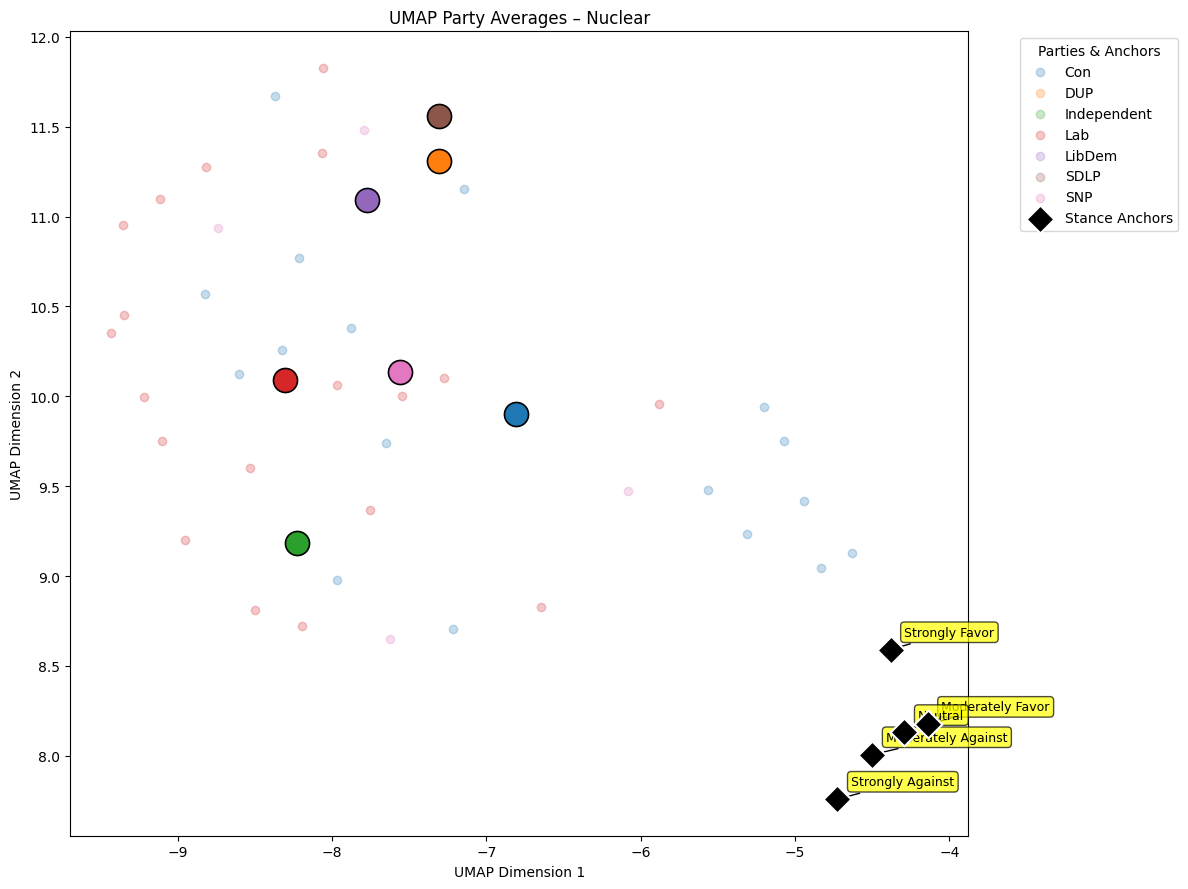

In [80]:
embeddings=uk.plot_umap_party_averages("nuclear", generate_anchors=True)

In [70]:
summaries=uk.summarize_parliamentary_speeches('gemma3',8, "nuclear")

PARLIAMENTARY SPEECH SUMMARIZATION WITH ROUGE SCORES
TOPIC: nuclear

────────────────────────────────────────────────────────────────────────────────────────────────────
SAMPLE 1/8
────────────────────────────────────────────────────────────────────────────────────────────────────

ORIGINAL TEXT:
We are not talking about rebuilding advanced gas-cooled reactors, which was a technology developed in the 1960s-it was advanced for the time, but is simply obsolete today.

SUMMARY:
The speaker opposes the development of advanced gas-cooled reactors, deeming them “obsolete” and unsuitable for current needs.

KEYWORDS FOUND: Advanced Gas-cooled Reactor

ROUGE SCORES:
  ROUGE-1: 0.3830
  ROUGE-2: 0.1333
  ROUGE-L: 0.2128

────────────────────────────────────────────────────────────────────────────────────────────────────
SAMPLE 2/8
────────────────────────────────────────────────────────────────────────────────────────────────────

ORIGINAL TEXT:
He told the House that there was evidence of a ca

In [ ]:
bullshit_sentences=[
    'Members will know, ASLEF declined to extend the rest day working agreement that ended in February.',
    'That is why standards of care have so deteriorated.',
    'There is a worry that there could be more failed trials, due to the difficulties in getting defendants and witnesses to court.',
    'It would be totally wrong, after agreeing a pensions policy across the political divide, to break it now and to put at a disadvantage people who have made arrangements for their retirement based on what was agreed after the Freud report was accepted.',
    'Defendants should never have to prove their own innocence.',
    'For example, at Preese Hall, the Environment Agency did not issue environmental permits for the disposal and management of flow-back waste water; it only discovered after the site had been hydraulically fractured that the flow-back fluid should be classified as radioactive waste.'
    ]

opinionated=[
    'Fans of satire will be listening to his comments with real interest, because the single biggest problem with the nuclear industry in this country can be traced back directly to the last Conservative Governments abysmal failure to deal with radioactive waste management.',
    'In a community such as mine, where the income of 55 percent of the population depends directly or indirectly on work in the nuclear industry, and in our country, where more than 20% of energy is generated by nuclear power plants, not having measures in place as we leave the EU and Euratom would be unthinkable.',
    "The truth is that the price people pay for nuclear power does not represent its true cost in terms of liabilities, decommissioning and clearing up after an accident."
]

## Gaza

In [71]:
uk_gaza=StanceDetector(df_small, records)
filtered_gaza= uk_gaza.filter_speeches("Gaza")
filtered_gaza.shape

BRO


(1592, 14)

In [72]:
classified_gaza=uk_gaza.classify_filtered_sentences("Gaza")
classified_gaza.shape

/var/folders/06/25_1mnt97hq60zy5672y3qzw0000gn/T/ipykernel_26971/595422711.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.record[topic]['df_filtered']['classification'] = predictions


(274, 15)

In [74]:
summaries=uk.summarize_parliamentary_speeches('gemma3',8, "Gaza")

PARLIAMENTARY SPEECH SUMMARIZATION WITH ROUGE SCORES
TOPIC: Gaza

────────────────────────────────────────────────────────────────────────────────────────────────────
SAMPLE 1/8
────────────────────────────────────────────────────────────────────────────────────────────────────

ORIGINAL TEXT:
Benjamin Netanyahu's recent speech was disappointing.

SUMMARY:
NO

KEYWORDS FOUND: Netanyahu, Benjamin Netanyahu

ROUGE SCORES:
  ROUGE-1: 0.0000
  ROUGE-2: 0.0000
  ROUGE-L: 0.0000

────────────────────────────────────────────────────────────────────────────────────────────────────
SAMPLE 2/8
────────────────────────────────────────────────────────────────────────────────────────────────────

ORIGINAL TEXT:
Ongoing humanitarian support for Palestinians is vital but, given the track record of Hamas in seeking to abuse and exploit UNRWA, what assurances will the Minister give about protecting the independence and integrity of UNRWA and ensuring that taxpayers' money is used to good effect?

SUMMA

In [63]:
summ=uk.summarize_parliamentary_speeches('gemma3',8, "nuclear")

PARLIAMENTARY SPEECH SUMMARIZATION WITH ROUGE SCORES
TOPIC: nuclear

────────────────────────────────────────────────────────────────────────────────────────────────────
SAMPLE 1/8
────────────────────────────────────────────────────────────────────────────────────────────────────

ORIGINAL TEXT:
It will not escape the attention of the workers of Sellafield-and, indeed, the voters of Copeland -that the Conservatives are not only seeking to make it more difficult for people to take action in specified industries, but robbing those people of their promised pensions.

SUMMARY:
**Opposes:** The speaker opposes the Conservative government's actions regarding Sellafield workers and their pensions, implying opposition to the broader use of nuclear energy due to its impact on workers' livelihoods.

KEYWORDS FOUND: Sellafield

ROUGE SCORES:
  ROUGE-1: 0.3421
  ROUGE-2: 0.0270
  ROUGE-L: 0.1842

────────────────────────────────────────────────────────────────────────────────────────────────────


## Climate change

In [ ]:
#idealmente uk non va reinizializzato ogni volta, ma visto che per aggiornare i cambiamenti nella classe devo ricrearlo lo faccio

In [10]:
uk=StanceDetector(df_small, records)
filtered_df= uk.filter_speeches("climate change")
classified_df = uk.classify_filtered_sentences("climate change")
complete_speeches_df = uk.get_full_discussions("climate change")
complete_speeches_df.shape

BRO


/var/folders/06/25_1mnt97hq60zy5672y3qzw0000gn/T/ipykernel_77328/1059098464.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.record[topic]['df_filtered']['classification'] = predictions


Retrieved 258 full discussions for topic 'climate change'


(258, 5)

In [13]:
complete_speeches_df.iloc[0]['speakers']

['Barry Sheerman',
 'Joan Ruddock',
 'David Heathcoat-Amory',
 'David Kidney',
 'Lindsay Hoyle',
 'Gregory Barker',
 'Charles Kennedy',
 'Ed Miliband',
 'Eric Illsley',
 'Christopher Chope',
 'Patricia Hewitt',
 'Greg Clark',
 'David Anderson',
 'Michael Weir']

In [30]:
summaries=uk.summarize_parliamentary_speeches('gemma3',8, "climate change")

PARLIAMENTARY SPEECH SUMMARIZATION WITH ROUGE SCORES
TOPIC: climate change

────────────────────────────────────────────────────────────────────────────────────────────────────
SAMPLE 1/8
────────────────────────────────────────────────────────────────────────────────────────────────────

ORIGINAL TEXT:
Does the Minister not recognise that the issue that really matters is how much fossil fuel is being burned and cannot be how much more renewable energy is being created if those renewables do not replace fossil fuels?

SUMMARY:
The Minister believes the primary concern is reducing fossil fuel consumption, arguing that increased renewable energy generation is ineffective without a corresponding decrease in fossil fuels.

KEYWORDS FOUND: renewable energy

ROUGE SCORES:
  ROUGE-1: 0.3750
  ROUGE-2: 0.1290
  ROUGE-L: 0.3438

────────────────────────────────────────────────────────────────────────────────────────────────────
SAMPLE 2/8
────────────────────────────────────────────────────────

In [6]:
nuclear_df=uk.filter_speeches('nuclear')

In [10]:
print(uk.format_discussion("Gaza", '21/01/2009'))

Clare Short (Independent): I am grateful for the opportunity to report to the House on my recent visit to Gaza. Also, I wish to press the Government to do more to uphold international law. It is my view, and that of many others, that if international law were upheld, there could and would be two states in Palestine, and we could look forward realistically to peace, but Israel constantly flouts international law, and the United States, the United Kingdom and the whole of the European Union collude in that. Thus, Israel concludes that might is right and uses its massive armaments to kill and bombard any who resist the constant expansion of its borders and land. Currently, we face the prospect of decades of bloodshed, conflict and bitterness in the middle east. We also see the authority of international law and the moral authority of the United Nations being eroded. That, alongside growing environmental strains and population growth in the poorest countries, promises a grim and disorderly

## Create opinon dataset for classification

In [17]:
OPINIONS= './../data/opinionated_sentences_uk_parliament.csv'
df_opinions=pd.read_csv(OPINIONS,names=["text"])

In [18]:
df_opinions["target"]="opinion"

In [19]:
df_opinions.head(10)

,text,target
0,It is my firm belief that unless this Governme...,opinion
1,"In my judgement, the fiscal framework laid out...",opinion
2,I must express my deep concern that the propos...,opinion
3,It seems abundantly clear to me that the Gover...,opinion
4,I strongly believe that our border and immigra...,opinion
5,"There is, in my view, a worrying complacency s...",opinion
6,It is painfully obvious that the deterioration...,opinion
7,I remain unconvinced that these educational re...,opinion
8,"From my perspective, the proposed digital regu...",opinion
9,I must stress that any attempt to modernise ou...,opinion


In [26]:
#from df take 30 random samples, keeping the text only
df_samples=df.sample(n=30, random_state=42)[['instance_id',"text"]]

In [27]:
df_samples["target"]="non_opinionated"
df_samples.head(10)

,instance_id,text,target
1779227,1779338,"As he knows, we requested that advice in a wri...",non_opinionated
6382789,6382909,We do not want to be in the situation of askin...,non_opinionated
3741183,3741301,Friend the Member for Barnsley East (Michael D...,non_opinionated
4529679,4529797,If the Minister cannot be persuaded to make a ...,non_opinionated
2549893,2550006,Friend also seemed to suggest that it was a ba...,non_opinionated
530432,530481,â€The European Scrutiny Committee stated that...,non_opinionated
5047828,5047946,Many sociologists these days consider the conc...,non_opinionated
3699877,3699995,We need to look at the capacity that we have a...,non_opinionated
3992428,3992546,"If Scunthorpe magistrates court closes, howeve...",non_opinionated
402703,402747,The Government resisted open-access for many y...,non_opinionated


In [29]:
#print all the text from df_samples formatting it in a readable way
for index, row in df_samples.iterrows():
    print(f" Text: {row['text']}\n, id: {row['instance_id']}\n")

 Text: As he knows, we requested that advice in a written parliamentary question last week.
, id: 1779338

 Text: We do not want to be in the situation of asking for another extension and, of course, for the requirement to undertake European Parliament elections.
, id: 6382909

 Text: Friend the Member for Barnsley East (Michael Dugher), the shadow Transport Secretary, has said, these are simple procedures but they make a big difference to people.
, id: 3741301

 Text: If the Minister cannot be persuaded to make a permanent change to the rules, surely he will consider a change to last for the duration of the current crisis.
, id: 4529797

 Text: Friend also seemed to suggest that it was a bad thing for newspapers to make corrections and put right errors, but in all the difficult negotiations we have had the press did not raise this as a problem; indeed, it is what the PCC already does.
, id: 2550006

 Text: â€The European Scrutiny Committee stated thatâ€œwe are disappointed that Membe

In [30]:
removed_ids=[4586726, 963539, 6518032, 160202, 2372336, 3040853, 5534816]  # example ids to remove and to be replaced with other random samples
df_final_samples=df_samples[~df_samples['instance_id'].isin(removed_ids)]
new_samples=df.sample(n=len(removed_ids), random_state=24)[['instance_id',"text"]]
new_samples["target"]="non_opinionated"
df_final_samples=pd.concat([df_final_samples, new_samples], ignore_index=True)



,instance_id,text,target
0,1779338,"As he knows, we requested that advice in a wri...",non_opinionated
1,6382909,We do not want to be in the situation of askin...,non_opinionated
2,3741301,Friend the Member for Barnsley East (Michael D...,non_opinionated
3,4529797,If the Minister cannot be persuaded to make a ...,non_opinionated
4,2550006,Friend also seemed to suggest that it was a ba...,non_opinionated
5,530481,â€The European Scrutiny Committee stated that...,non_opinionated
6,5047946,Many sociologists these days consider the conc...,non_opinionated
7,3699995,We need to look at the capacity that we have a...,non_opinionated
8,3992546,"If Scunthorpe magistrates court closes, howeve...",non_opinionated
9,402747,The Government resisted open-access for many y...,non_opinionated


In [32]:
df_final_samples.drop('instance_id', axis=1, inplace=True)

In [34]:
dataset = pd.concat([df_final_samples, df_opinions], ignore_index=True)
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle the dataset
dataset.to_csv('./../data/opinion_dataset.csv', index=False)

## embeddings

In [4]:
def plot_umap_embeddings(sentences,
                         model_name="all-MiniLM-L6-v2",
                         n_components=2,
                         n_neighbors=10,
                         min_dist=0.1,
                         metric="cosine"):
    """
    Encodes sentences using a SentenceTransformer model, reduces the embeddings
    with UMAP, and plots the resulting 2D or 3D projection.

    Parameters
    ----------
    sentences : list of str
        The sentences to encode and project.
    model_name : str
        Name of the pretrained SentenceTransformer model.
    n_components : int
        Dimensionality of the UMAP output (2 or 3).
    n_neighbors : int
        UMAP parameter controlling local vs global structure.
    min_dist : float
        UMAP parameter controlling how tightly points may cluster.
    metric : str
        Distance metric for UMAP (cosine is recommended for embeddings).
    """

    # 1. Load model
    model = SentenceTransformer(model_name)

    # 2. Encode sentences
    embeddings = model.encode(sentences)

    # 3. UMAP dimensionality reduction
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    reduced = reducer.fit_transform(embeddings)

    # 4. Plot
    if n_components == 2:
        plt.figure(figsize=(10, 7))
        plt.scatter(reduced[:, 0], reduced[:, 1])

        for i, sentence in enumerate(sentences):
            plt.text(reduced[i, 0] + 0.01,
                     reduced[i, 1] + 0.01,
                     str(i),
                     fontsize=9)
        
        plt.title("UMAP Projection")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")
        plt.show()

    elif n_components == 3:
        from mpl_toolkits.mplot3d import Axes3D  # only needed for 3D
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2])

        for i, sentence in enumerate(sentences):
            ax.text(reduced[i, 0],
                    reduced[i, 1],
                    reduced[i, 2],
                    str(i),
                    fontsize=9)

        ax.set_title("UMAP 3D Projection")
        ax.set_xlabel("UMAP-1")
        ax.set_ylabel("UMAP-2")
        ax.set_zlabel("UMAP-3")
        plt.show()

    else:
        raise ValueError("n_components must be 2 or 3")

    return reduced